In [20]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# load the pharmacy sales dataset
df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")

# check shape of data
print("Rows and Columns:", df.shape)

# check first 5 rows
df.head()

Rows and Columns: (177990, 14)


,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0


In [22]:
# check column data types
print(df.dtypes)

# check basic statistics of numeric columns
df.describe()

date                      object
year                       int64
month                      int64
day                        int64
region                    object
country                   object
category                  object
medicine                  object
age_group                 object
units_sold                 int64
unit_price               float64
stock_level                int64
expiry_days_remaining      int64
covid_flag                 int64
dtype: object


,year,month,day,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
count,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000
mean,2022.499702,6.521754,15.730457,447.913849,52.554729,4552.991780,374.038109,0.333519
std,1.708113,3.448703,8.801170,338.924528,27.421909,346.608511,199.759193,0.471471
min,2020.000000,1.000000,1.000000,31.000000,5.000000,0.000000,30.000000,0.000000
25%,2021.000000,4.000000,8.000000,284.000000,28.770000,4443.000000,200.000000,0.000000
50%,2023.000000,7.000000,16.000000,387.000000,52.600000,4598.000000,374.000000,0.000000
75%,2024.000000,10.000000,23.000000,529.000000,76.310000,4735.000000,547.000000,1.000000
max,2025.000000,12.000000,31.000000,8704.000000,100.000000,5124.000000,720.000000,1.000000


In [23]:
# list of numeric columns we want to check for outliers
numeric_cols = ["units_sold", "unit_price", "stock_level", "expiry_days_remaining"]

# print numeric columns
print(numeric_cols)

['units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining']


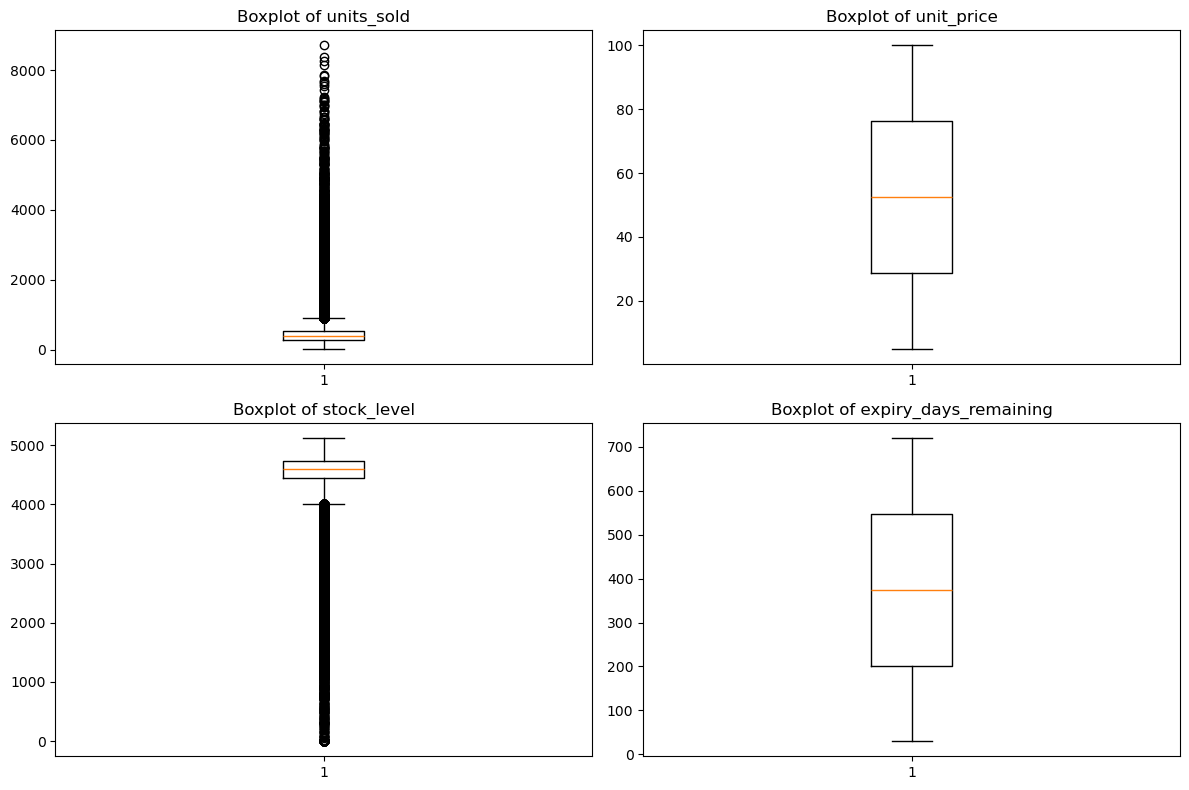

In [24]:
# boxplot for each numeric column to visualize outliers
plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i+1)          # create grid of 2x2 plots
    plt.boxplot(df[col])            # draw boxplot
    plt.title("Boxplot of " + col)  # add title

plt.tight_layout()
plt.show()

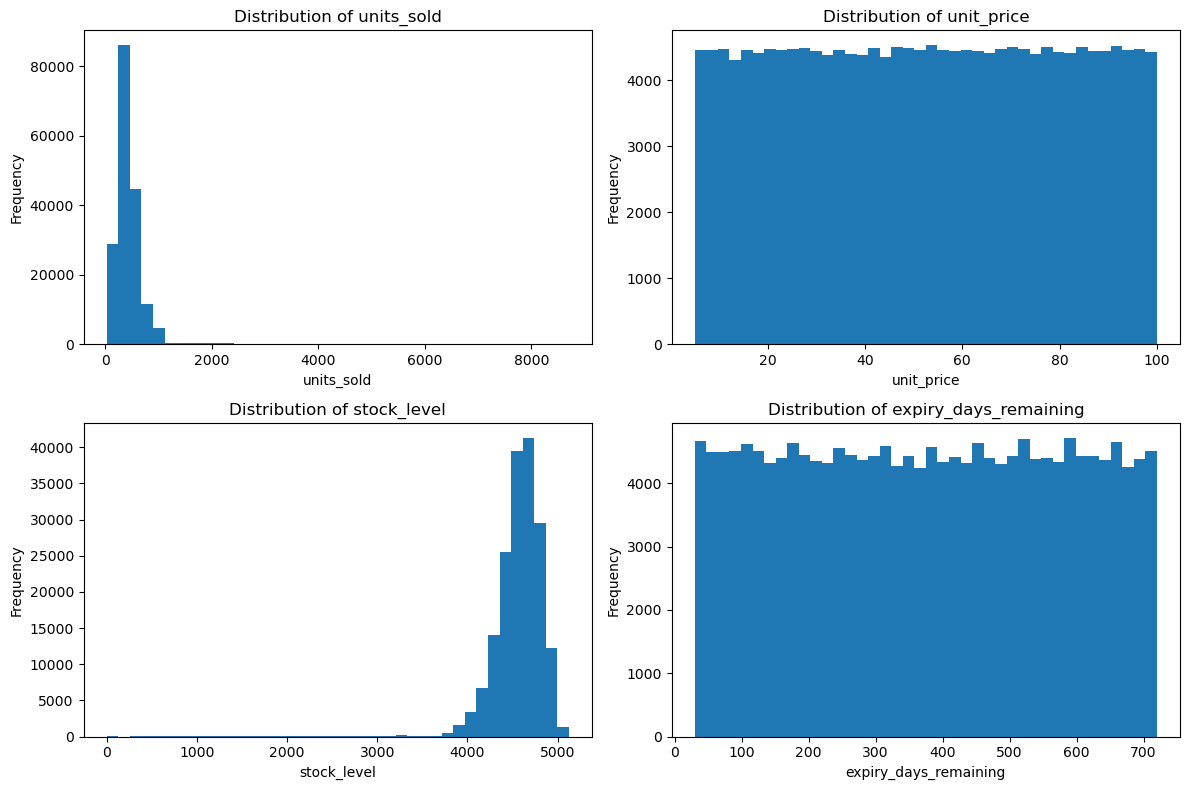

In [ ]:
# histogram to see distribution of each numeric column
plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i+1) # create grid of 2x2 plots
    plt.hist(df[col], bins=40)  # draw histogram
    plt.title("Distribution of " + col)     # add title
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

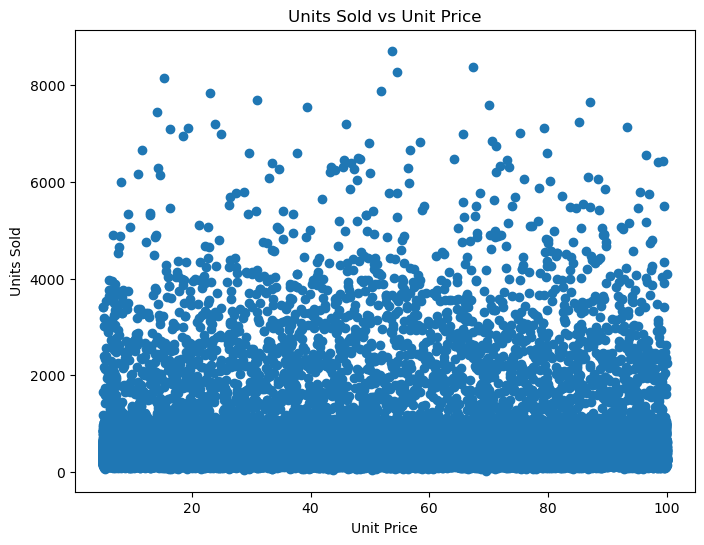

In [ ]:
# scatterplot to see relation between units_sold and unit_price
plt.figure(figsize=(8, 6))
plt.scatter(df["unit_price"], df["units_sold"])
plt.title("Units Sold vs Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.show()

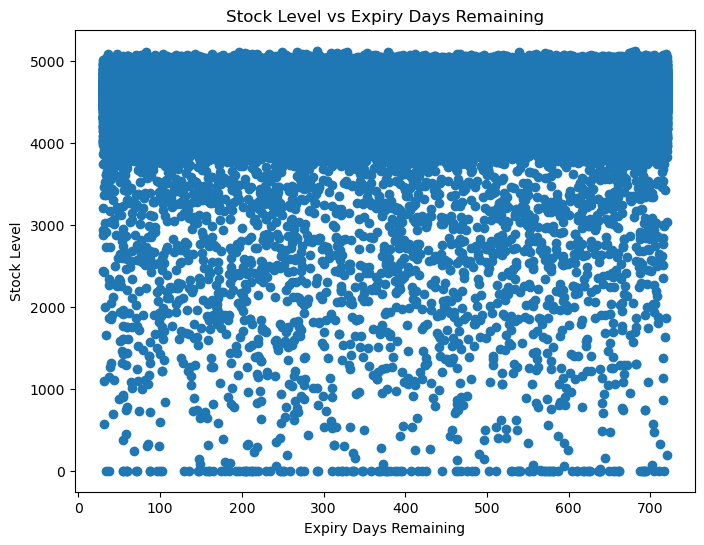

In [ ]:
# scatterplot to see relation between stock_level and expiry_days_remaining
plt.figure(figsize=(8, 6))
plt.scatter(df["expiry_days_remaining"], df["stock_level"])
plt.title("Stock Level vs Expiry Days Remaining")
plt.xlabel("Expiry Days Remaining")
plt.ylabel("Stock Level")
plt.show()

In [ ]:
# function to find outliers using IQR method
def find_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)     # first quartile
    Q3 = data[col].quantile(0.75)     # third quartile
    IQR = Q3 - Q1                     # inter quartile range

    lower_limit = Q1 - 1.5 * IQR      # lower boundary
    upper_limit = Q3 + 1.5 * IQR      # upper boundary

    # filter rows which are outliers
    outliers = data[(data[col] < lower_limit) | (data[col] > upper_limit)]
    return outliers, lower_limit, upper_limit

# check outliers for each numeric column
for col in numeric_cols:
    outliers, low, high = find_outliers_iqr(df, col)
    print(col, "-> Lower Limit:", round(low,2), " Upper Limit:", round(high,2), " Outlier Count:", len(outliers))

units_sold -> Lower Limit: -83.5  Upper Limit: 896.5  Outlier Count: 6899
unit_price -> Lower Limit: -42.54  Upper Limit: 147.62  Outlier Count: 0
stock_level -> Lower Limit: 4005.0  Upper Limit: 5173.0  Outlier Count: 4831
expiry_days_remaining -> Lower Limit: -320.5  Upper Limit: 1067.5  Outlier Count: 0


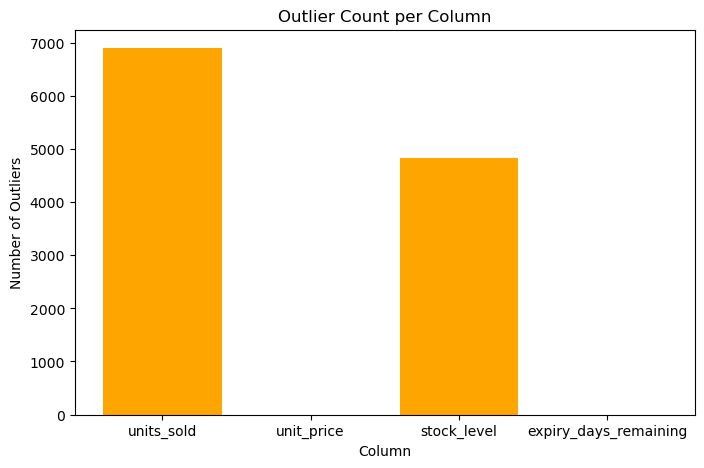

In [ ]:
# store outlier counts in a list to plot bar chart
outlier_counts = []

for col in numeric_cols:
    outliers, low, high = find_outliers_iqr(df, col)
    outlier_counts.append(len(outliers))

# bar chart of outlier counts per column
plt.figure(figsize=(8, 5))
plt.bar(numeric_cols, outlier_counts, color="orange")
plt.title("Outlier Count per Column")
plt.xlabel("Column")
plt.ylabel("Number of Outliers")
plt.show()

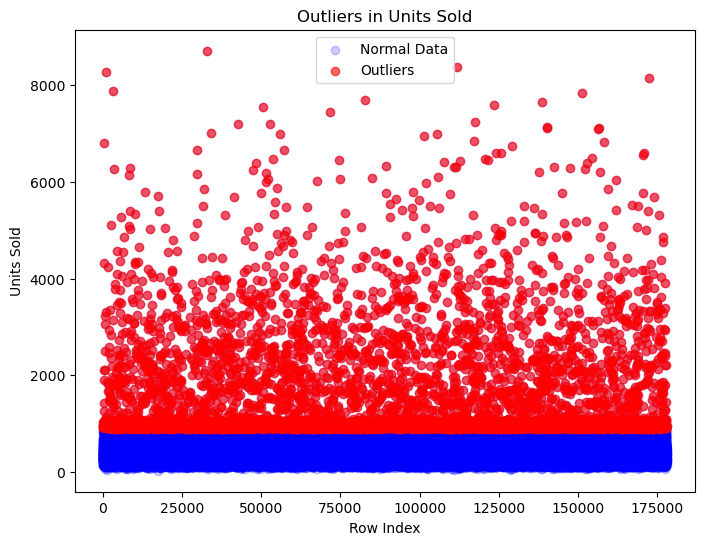

In [ ]:
# highlight outliers in units_sold column using scatterplot
outliers, low, high = find_outliers_iqr(df, "units_sold")

plt.figure(figsize=(8, 6))

# plot normal points in blue
plt.scatter(df.index, df["units_sold"], alpha=0.2, color="blue", label="Normal Data")

# plot outlier points in red
plt.scatter(outliers.index, outliers["units_sold"], alpha=0.6, color="red", label="Outliers")

plt.title("Outliers in Units Sold")
plt.xlabel("Row Index")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

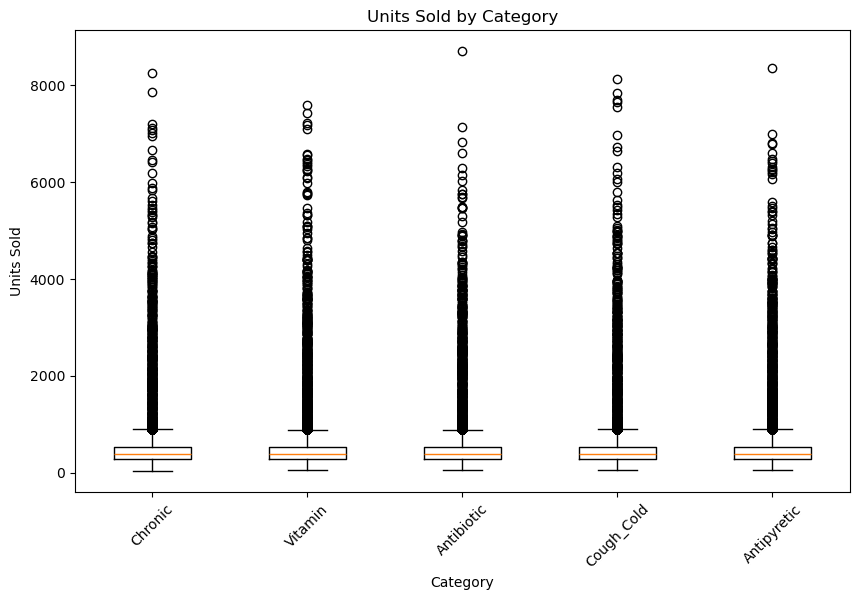

In [ ]:
# boxplot of units_sold grouped by medicine category to see outliers category wise
categories = df["category"].unique()
data_by_category = [df[df["category"] == cat]["units_sold"] for cat in categories]

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_category, tick_labels=categories)
plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ------------------------------------------------------------
# Impact of outliers on model performance:
# 1. Outliers can pull the mean and standard deviation away from true center,
#    causing biased statistical summaries.
# 2. Linear models (Linear Regression) are highly sensitive to outliers,
#    since they minimize squared error, outliers get extra weight.
# 3. Distance based models (KNN, KMeans) get affected because outliers
#    change distance calculations.
# 4. Tree based models (Decision Tree, Random Forest, XGBoost) are less
#    sensitive to outliers compared to linear/distance based models.
# 5. Outliers can lead to overfitting if the model tries to learn
#    from these rare/extreme points.
# ------------------------------------------------------------
print("Outlier impact analysis printed above as comments")

Outlier impact analysis printed above as comments


In [ ]:
# ------------------------------------------------------------
# Mitigation strategies for handling outliers:
# 1. Capping / Winsorization -> replace extreme values with the
#    upper/lower limit calculated from IQR method.
# 2. Removal -> drop outlier rows if they are very few in number
#    and are due to data entry errors.
# 3. Transformation -> apply log or square root transformation to
#    reduce the effect of large values.
# 4. Use Robust Models -> tree based models (Random Forest, XGBoost)
#    naturally handle outliers better than linear models.
# 5. Separate Analysis -> sometimes outliers represent real events
#    (like COVID demand spike) and should be studied separately
#    instead of removing them.
# ------------------------------------------------------------
print("Mitigation strategies printed above as comments")

Mitigation strategies printed above as comments


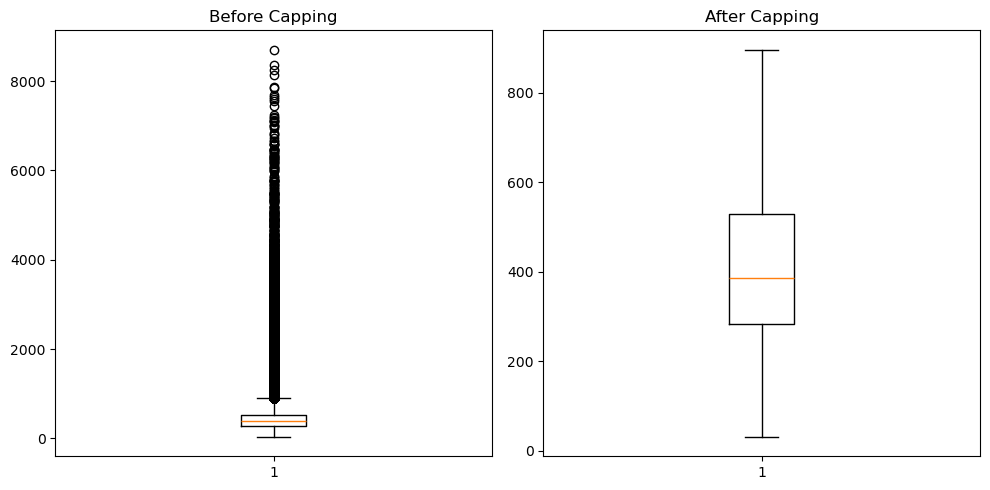

In [ ]:
# example: capping outliers in units_sold column using IQR limits
outliers, low, high = find_outliers_iqr(df, "units_sold")

# create a copy of column with capped values
df["units_sold_capped"] = df["units_sold"].clip(lower=low, upper=high)

# compare boxplot before and after capping
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df["units_sold"])
plt.title("Before Capping")

plt.subplot(1, 2, 2)
plt.boxplot(df["units_sold_capped"])
plt.title("After Capping")

plt.tight_layout()
plt.show()